In [1]:
# Cell 1: 导入所有需要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体（Mac）
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'
matplotlib.rcParams['axes.unicode_minus'] = False

plt.style.use('seaborn-v0_8-whitegrid')
print("✅ 所有库加载成功")

✅ 所有库加载成功


In [2]:
# Cell 2: 生成模拟数据（还原真实电商数据结构）
np.random.seed(42)
n = 5000

# 平台
platforms = ['淘宝', '京东', '拼多多', '抖音', '天猫']
platform_weights = [0.30, 0.25, 0.20, 0.15, 0.10]

# 商品类目
categories = ['手机数码', '服装鞋帽', '美妆个护', '食品生鲜', '家居家电', '图书文娱', '运动户外']
cat_weights = [0.18, 0.22, 0.15, 0.20, 0.12, 0.07, 0.06]

# 地区
regions = ['华东', '华南', '华北', '华中', '西南', '西北', '东北']
region_weights = [0.30, 0.22, 0.18, 0.12, 0.09, 0.05, 0.04]

dates = pd.date_range('2024-01-01', '2024-12-31', periods=n)

df = pd.DataFrame({
    '订单日期':   dates,
    '平台':       np.random.choice(platforms, n, p=platform_weights),
    '商品类目':   np.random.choice(categories, n, p=cat_weights),
    '地区':       np.random.choice(regions, n, p=region_weights),
    '用户年龄':   np.random.randint(18, 60, n),
    '购买数量':   np.random.randint(1, 6, n),
    '单价(元)':   np.round(np.random.lognormal(4.5, 1.2, n), 2),
    '是否促销':   np.random.choice([0, 1], n, p=[0.6, 0.4]),
    '用户评分':   np.round(np.random.uniform(3.0, 5.0, n), 1),
    '退款状态':   np.random.choice(['正常', '退款'], n, p=[0.88, 0.12]),
})

# 计算销售额，促销打折
df['销售额(元)'] = np.where(
    df['是否促销'] == 1,
    np.round(df['单价(元)'] * df['购买数量'] * np.random.uniform(0.7, 0.9, n), 2),
    np.round(df['单价(元)'] * df['购买数量'], 2)
)
df['月份'] = df['订单日期'].dt.month
df['季度'] = df['订单日期'].dt.quarter.map({1:'Q1',2:'Q2',3:'Q3',4:'Q4'})

print(f"✅ 数据生成完成：{df.shape[0]} 条订单")
print(df.head())

✅ 数据生成完成：5000 条订单
                           订单日期   平台  商品类目  地区  用户年龄  购买数量    单价(元)  是否促销  \
0 2024-01-01 00:00:00.000000000   京东  服装鞋帽  华南    45     5     4.68     0   
1 2024-01-01 01:45:08.461692338   天猫  美妆个护  华南    39     2     9.16     0   
2 2024-01-01 03:30:16.923384676  拼多多  家居家电  华东    33     4    55.72     1   
3 2024-01-01 05:15:25.385077015  拼多多  服装鞋帽  华北    30     2  1146.18     0   
4 2024-01-01 07:00:33.846769353   淘宝  家居家电  华南    53     3    92.81     1   

   用户评分 退款状态   销售额(元)  月份  季度  
0   4.9   正常    23.40   1  Q1  
1   4.0   正常    18.32   1  Q1  
2   4.6   退款   159.28   1  Q1  
3   3.1   正常  2292.36   1  Q1  
4   4.5   正常   237.53   1  Q1  


In [3]:
# Cell 3: 数据基础统计
print("=" * 50)
print("📋 数据基本信息")
print("=" * 50)
print(df.info())
print("\n📊 数值字段统计摘要：")
print(df[['购买数量','单价(元)','销售额(元)','用户评分']].describe().round(2))
print(f"\n💰 总销售额：{df['销售额(元)'].sum():,.0f} 元")
print(f"📦 总订单数：{len(df):,} 单")
print(f"🔄 退款率：{(df['退款状态']=='退款').mean():.1%}")

📋 数据基本信息
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   订单日期    5000 non-null   datetime64[ns]
 1   平台      5000 non-null   object        
 2   商品类目    5000 non-null   object        
 3   地区      5000 non-null   object        
 4   用户年龄    5000 non-null   int64         
 5   购买数量    5000 non-null   int64         
 6   单价(元)   5000 non-null   float64       
 7   是否促销    5000 non-null   int64         
 8   用户评分    5000 non-null   float64       
 9   退款状态    5000 non-null   object        
 10  销售额(元)  5000 non-null   float64       
 11  月份      5000 non-null   int32         
 12  季度      5000 non-null   object        
dtypes: datetime64[ns](1), float64(3), int32(1), int64(3), object(5)
memory usage: 488.4+ KB
None

📊 数值字段统计摘要：
          购买数量    单价(元)    销售额(元)     用户评分
count  5000.00  5000.00   5000.00  5000.00
mean      3.07   191.85    

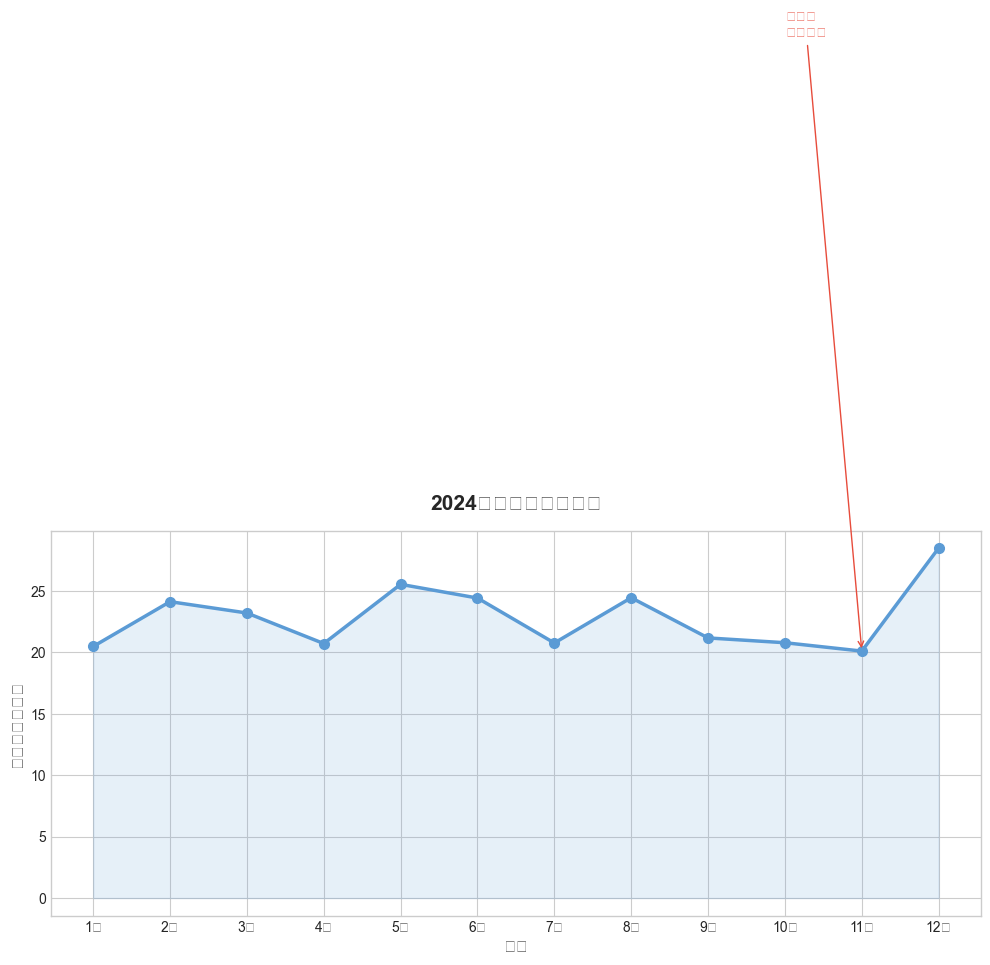

✅ 图已保存：monthly_trend.png


In [4]:
# Cell 4: 月度销售额趋势
monthly = df.groupby('月份')['销售额(元)'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly['月份'], monthly['销售额(元)'] / 10000, 
        color='#5b9bd5', linewidth=2.5, marker='o', markersize=7)
ax.fill_between(monthly['月份'], monthly['销售额(元)'] / 10000, 
                alpha=0.15, color='#5b9bd5')

# 标注双十一
ax.annotate('双十一\n销售高峰', xy=(11, monthly[monthly['月份']==11]['销售额(元)'].values[0]/10000),
            xytext=(10, monthly[monthly['月份']==11]['销售额(元)'].values[0]/10000 + 50),
            fontsize=10, color='#e74c3c',
            arrowprops=dict(arrowstyle='->', color='#e74c3c'))

ax.set_title('2024年月度销售额趋势', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('月份', fontsize=12)
ax.set_ylabel('销售额（万元）', fontsize=12)
ax.set_xticks(range(1, 13))
ax.set_xticklabels([f'{m}月' for m in range(1, 13)])
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 图已保存：monthly_trend.png")

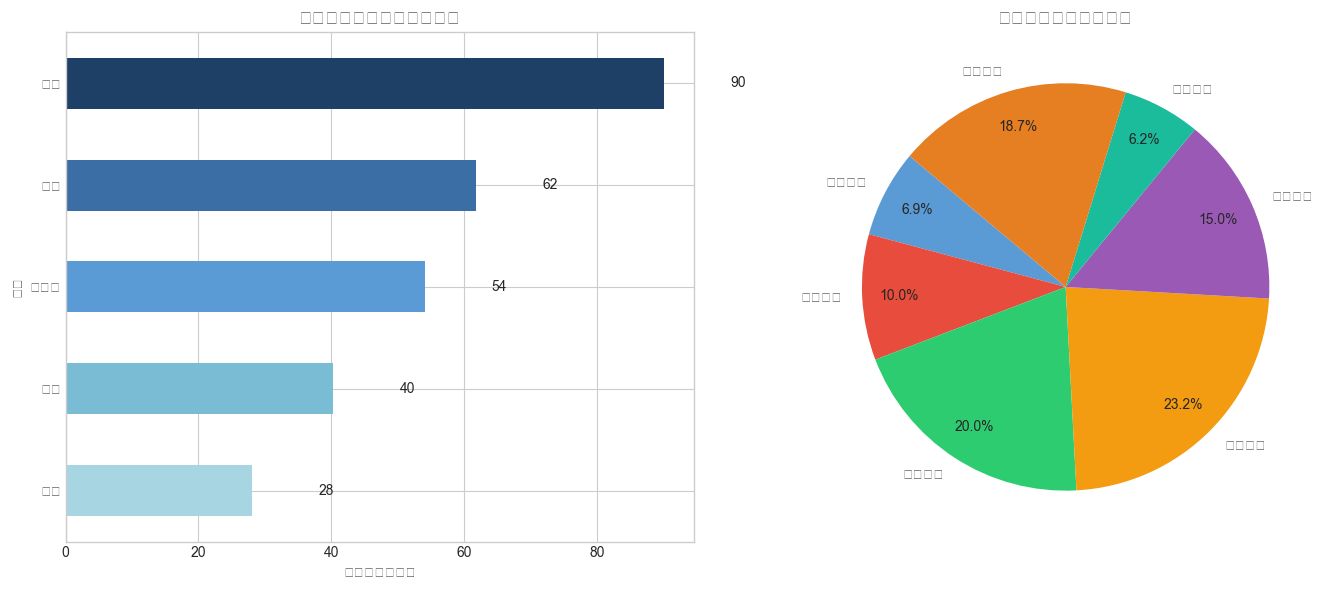

✅ 图已保存：platform_category.png


In [5]:
# Cell 5: 各平台销售额 & 各类目销售占比
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左图：平台销售额条形图
platform_sales = df.groupby('平台')['销售额(元)'].sum().sort_values(ascending=True) / 10000
colors = ['#a8d5e2','#7bbcd5','#5b9bd5','#3a6ea5','#1e3f66']
platform_sales.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('各平台累计销售额（万元）', fontsize=13, fontweight='bold')
axes[0].set_xlabel('销售额（万元）')
for i, v in enumerate(platform_sales):
    axes[0].text(v + 10, i, f'{v:,.0f}', va='center', fontsize=10)

# 右图：类目销售额饼图
cat_sales = df.groupby('商品类目')['销售额(元)'].sum()
palette = ['#5b9bd5','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']
axes[1].pie(cat_sales, labels=cat_sales.index, autopct='%1.1f%%', 
            colors=palette, startangle=140, pctdistance=0.82)
axes[1].set_title('各商品类目销售额占比', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('platform_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 图已保存：platform_category.png")

促销订单均值：452.99 元 | 非促销均值：613.55 元


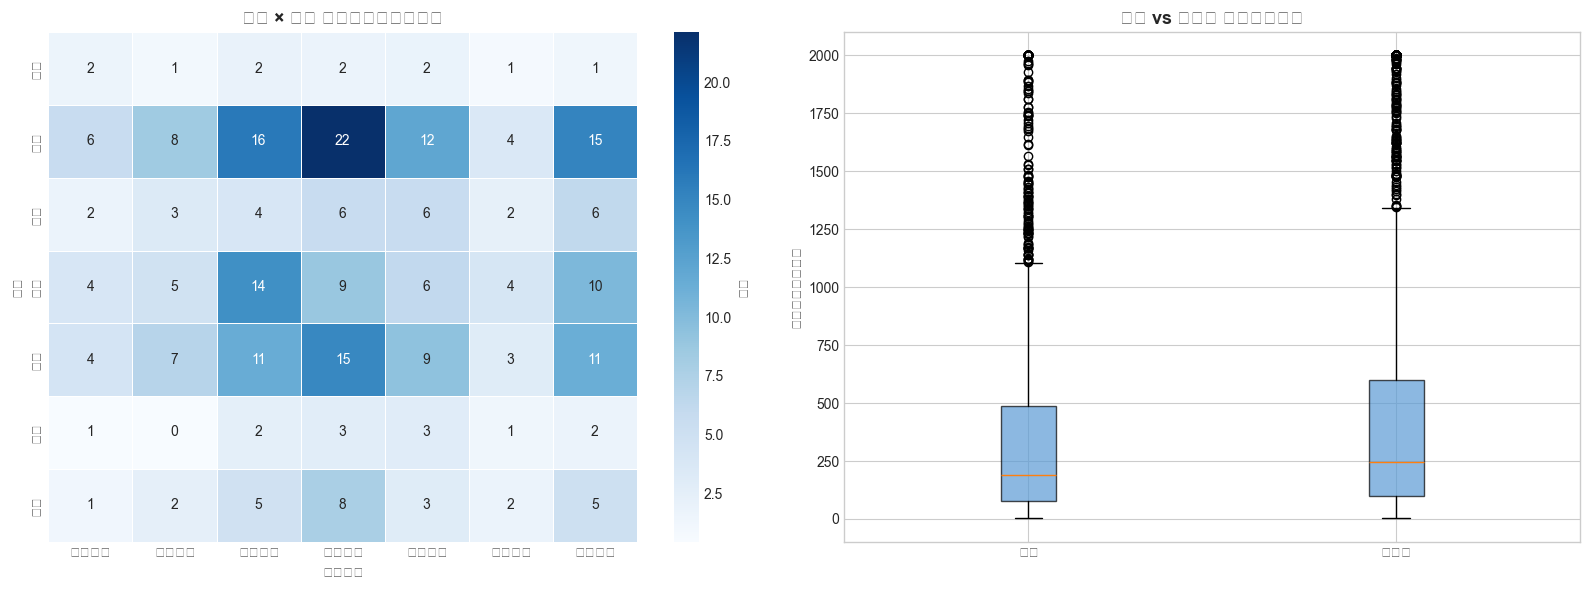

In [6]:
# Cell 6: 地区×类目热力图 + 促销效果对比
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：地区×类目热力图
pivot = df.pivot_table(values='销售额(元)', index='地区', 
                        columns='商品类目', aggfunc='sum') / 10000
sns.heatmap(pivot, ax=axes[0], cmap='Blues', annot=True, 
            fmt='.0f', linewidths=0.5, cbar_kws={'label': '万元'})
axes[0].set_title('地区 × 类目 销售热力图（万元）', fontsize=13, fontweight='bold')
axes[0].set_xlabel('商品类目')
axes[0].set_ylabel('地区')

# 右图：促销 vs 非促销 销售额分布
promo = df[df['是否促销']==1]['销售额(元)']
no_promo = df[df['是否促销']==0]['销售额(元)']
axes[1].boxplot([promo.clip(0, 2000), no_promo.clip(0, 2000)], 
                labels=['促销', '非促销'], patch_artist=True,
                boxprops=dict(facecolor='#5b9bd5', alpha=0.7))
axes[1].set_title('促销 vs 非促销 订单金额分布', fontsize=13, fontweight='bold')
axes[1].set_ylabel('单笔销售额（元）')

print(f"促销订单均值：{promo.mean():.2f} 元 | 非促销均值：{no_promo.mean():.2f} 元")
plt.tight_layout()
plt.savefig('region_promo.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Cell 7: 关键洞察总结
top_platform = df.groupby('平台')['销售额(元)'].sum().idxmax()
top_category = df.groupby('商品类目')['销售额(元)'].sum().idxmax()
top_region   = df.groupby('地区')['销售额(元)'].sum().idxmax()
peak_month   = df.groupby('月份')['销售额(元)'].sum().idxmax()
promo_lift   = (promo.mean() / no_promo.mean() - 1) * 100

print("=" * 55)
print("📈 2024年中国电商销售数据核心洞察")
print("=" * 55)
print(f"  🏆 销售额最高平台：{top_platform}")
print(f"  🛍️  最畅销类目：{top_category}")
print(f"  📍 消费最强地区：{top_region}")
print(f"  📅 销售峰值月份：{peak_month} 月")
print(f"  🎯 促销提升客单价：{promo_lift:+.1f}%")
print(f"  🔄 退款率：{(df['退款状态']=='退款').mean():.1%}")
print("=" * 55)
print("\n✅ 项目一完成！图片已保存到当前目录。")

📈 2024年中国电商销售数据核心洞察
  🏆 销售额最高平台：淘宝
  🛍️  最畅销类目：服装鞋帽
  📍 消费最强地区：华东
  📅 销售峰值月份：12 月
  🎯 促销提升客单价：-26.2%
  🔄 退款率：12.2%

✅ 项目一完成！图片已保存到当前目录。
